In [14]:
# !pip install -q --upgrade torch==2.5.1+cu124 torchvision==0.20.1+cu124 torchaudio==2.5.1+cu124 --index-url https://download.pytorch.org/whl/cu124

!pip install -q datasets requests peft bitsandbytes transformers==4.48.3 accelerate==1.3.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.6/336.6 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 120.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 872.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
import os, re, math
from datetime import datetime
os.environ['HF_HOME'] = "data/huggingface"
os.environ['CLOUD_PROVIDER'] = "google"

In [2]:
from datasets import load_dataset, Dataset, DatasetDict
import matplotlib.pyplot as plt
%matplotlib inline

from tqdm import tqdm
import torch, transformers
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, TrainingArguments, set_seed
from peft import LoraConfig, PeftModel

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

In [3]:
from huggingface_hub import login

if os.getenv("CLOUD_PROVIDER") == "google":
    from google.colab import userdata
    hf_token = userdata.get('HF_TOKEN')
    login(hf_token, add_to_git_credential=True)

In [5]:
# Tokenizers
#LLAMA_3_1 = "meta-llama/Meta-Llama-3.1-8B"
QWEN_2_5 = "Qwen/Qwen2.5-7B"
GEMMA_2 = "google/gemma-2-9b"
PHI_3 = "microsoft/Phi-3-medium-4k-instruct"

# Constants
BASE_MODEL = "mistralai/Mistral-7B-v0.3"
DATASET_NAME = "ed-donner/pricer-data"
MAX_SEQUENCE_LENGTH = 182
QUANT_4_BIT = True
# Used for writing to output in color
COLOR_MAP = {"red": "\033[91m", "orange": "\033[93m", "green": "\033[92m", "reset": "\033[0m"}

In [6]:
def investigate_tokenizer(model_name):
    print("Investigating tokenizer for", model_name)
    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True) # cache_dir

    for number in [0, 1, 10, 100, 999, 1000]:
        tokens = tokenizer.encode(str(number), add_special_tokens=False)
        print(f"The tokens for {number}: {tokens}")

In [7]:
# Now we will try this with each model: LLAMA_3_1, QWEN_2_5, GEMMA_2, PHI_3

investigate_tokenizer(PHI_3)

Investigating tokenizer for microsoft/Phi-3-medium-4k-instruct
The tokens for 0: [29871, 29900]
The tokens for 1: [29871, 29896]
The tokens for 10: [29871, 29896, 29900]
The tokens for 100: [29871, 29896, 29900, 29900]
The tokens for 999: [29871, 29929, 29929, 29929]
The tokens for 1000: [29871, 29896, 29900, 29900, 29900]


In [8]:
!ls -al data/huggingface

total 28
drwxr-xr-x 5 root root 4096 Aug  5 02:56 .
drwxr-xr-x 3 root root 4096 Aug  5 02:54 ..
drwxr-xr-x 3 root root 4096 Aug  5 02:56 datasets
drwxr-xr-x 6 root root 4096 Aug  5 03:01 hub
-rw-r--r-- 1 root root   59 Aug  5 03:01 stored_tokens
-rw-r--r-- 1 root root   37 Aug  5 03:01 token
drwxr-xr-x 3 root root 4096 Aug  5 02:55 xet


In [11]:
dataset = load_dataset(DATASET_NAME)
train, test = dataset['train'], dataset['test']

In [12]:
test[0]

{'text': "How much does this cost to the nearest dollar?\n\nOEM AC Compressor w/A/C Repair Kit For Ford F150 F-150 V8 & Lincoln Mark LT 2007 2008 - BuyAutoParts NEW\nAs one of the world's largest automotive parts suppliers, our parts are trusted every day by mechanics and vehicle owners worldwide. This A/C Compressor and Components Kit is manufactured and tested to the strictest OE standards for unparalleled performance. Built for trouble-free ownership and 100% visually inspected and quality tested, this A/C Compressor and Components Kit is backed by our 100% satisfaction guarantee. Guaranteed Exact Fit for easy installation 100% BRAND NEW, premium ISO/TS 16949 quality - tested to meet or exceed OEM specifications Engineered for superior durability, backed by industry-leading unlimited-mileage warranty Included in this K\n\nPrice is $",
 'price': 374.41}

In [13]:
if QUANT_4_BIT:
    quant_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.bfloat16,

        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
    )
else:
    quant_config = BitsAndBytesConfig(
        load_in_8bit=True,
        bnb_8bit_compute_dtype=torch.bfloat16,
    )

In [14]:
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=quant_config,
    device_map="auto",
)
base_model.generation_config.pad_token_id = tokenizer.pad_token_id

print(f"Memory footprint: {base_model.get_memory_footprint() / 1e9:.1f} GB")

model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

model-00001-of-00003.safetensors:   0%|          | 0.00/4.95G [00:00<?, ?B/s]

model-00002-of-00003.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/4.55G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Memory footprint: 4.0 GB


In [15]:
def extract_price(s):
    if "Price is $" in s:
        contents = s.split("Price is $")[1]
        contents = contents.replace(',','').replace('$','')
        match = re.search(r"[-+]?\d*\.\d+|\d+", contents)
        return float(match.group()) if match else 0

    return 0

extract_price("Price is $999 blah blah so cheap")

999.0

In [16]:
def model_predict(prompt):
    set_seed(42)
    inputs = tokenizer.encode(prompt, return_tensors="pt").to("cuda")
    attention_mask = torch.ones(inputs.shape, device="cuda")

    outputs = base_model.generate(inputs, attention_mask=attention_mask, max_new_tokens=4, num_return_sequences=1)
    response = tokenizer.decode(outputs[0])
    return extract_price(response)

model_predict(test[0]['text'])

100.0

In [20]:
class Tester:
    def __init__(self, predictor, data, title=None, size=250):
        self.predictor = predictor
        self.data = data
        self.title = title or predictor.__name__.replace("_", " ").title()
        self.size = size

        self.guesses = []
        self.truths = []
        self.errors = []
        self.sles = []
        self.colors = []

    def color_for(self, error, truth):
        if error<40 or error/truth < 0.2:
            return "green"
        elif error<80 or error/truth < 0.4:
            return "orange"
        else:
            return "red"

    def run_datapoint(self, i):
        datapoint = self.data[i]
        guess = self.predictor(datapoint["text"])

        truth = datapoint["price"]
        error = abs(guess - truth)
        log_error = math.log(truth+1) - math.log(guess+1)
        sle = log_error ** 2
        color = self.color_for(error, truth)
        title = datapoint["text"].split("\n\n")[1][:20] + "..."

        self.guesses.append(guess)
        self.truths.append(truth)
        self.errors.append(error)
        self.sles.append(sle)
        self.colors.append(color)

        print(f"{COLOR_MAP[color]}{i+1}: Guess: ${guess:,.2f} Truth: ${truth:,.2f} Error: ${error:,.2f} SLE: {sle:,.2f} Item: {title}{COLOR_MAP['reset']}")

    def chart(self, title):
        max_error = max(self.errors)
        max_val = max(max(self.truths), max(self.guesses))

        plt.figure(figsize=(12, 8))
        plt.plot([0, max_val], [0, max_val], color='deepskyblue', lw=2, alpha=0.6)
        plt.scatter(self.truths, self.guesses, s=3, c=self.colors)
        plt.xlabel('Ground Truth')
        plt.ylabel('Model Estimate')
        plt.xlim(0, max_val)
        plt.ylim(0, max_val)
        plt.title(title)
        plt.show()

    def report(self):
        average_error = sum(self.errors) / self.size
        rmsle = math.sqrt(sum(self.sles) / self.size)
        hits = sum(1 for color in self.colors if color=="green")
        title = f"{self.title} Error=${average_error:,.2f} RMSLE={rmsle:,.2f} Hits={hits/self.size*100:.1f}%"
        self.chart(title)

    def run(self):
        self.error = 0
        for i in range(self.size):
            self.run_datapoint(i)

        self.report()

    @classmethod
    def test(cls, function, data):
        cls(function, data).run()

1: Guess: $100.00 Truth: $374.41 Error: $274.41 SLE: 1.72 Item: OEM AC Compressor w/...
2: Guess: $10.90 Truth: $225.11 Error: $214.21 SLE: 8.67 Item: Motorcraft YB3125 Fa...
3: Guess: $10.90 Truth: $61.68 Error: $50.78 SLE: 2.76 Item: Dorman Front Washer ...
4: Guess: $599.00 Truth: $599.99 Error: $0.99 SLE: 0.00 Item: HP Premium HD Plus T...
5: Guess: $10.00 Truth: $16.99 Error: $6.99 SLE: 0.24 Item: Super Switch Pickup ...
6: Guess: $10.90 Truth: $31.99 Error: $21.09 SLE: 1.04 Item: Horror Bookmarks, Re...
7: Guess: $100.00 Truth: $101.79 Error: $1.79 SLE: 0.00 Item: SK6241 - Stinger 4 G...
8: Guess: $199.00 Truth: $289.00 Error: $90.00 SLE: 0.14 Item: Godox ML60Bi LED Lig...
9: Guess: $100.00 Truth: $635.86 Error: $535.86 SLE: 3.39 Item: Randall G3 Plus Comb...
10: Guess: $100.00 Truth: $65.99 Error: $34.01 SLE: 0.17 Item: HOLDWILL 6 Pack LED ...
11: Guess: $199.00 Truth: $254.21 Error: $55.21 SLE: 0.06 Item: Viking Horns 3 Gallo...
12: Guess: $100.00 Truth: $412.99 Error: $312.99 

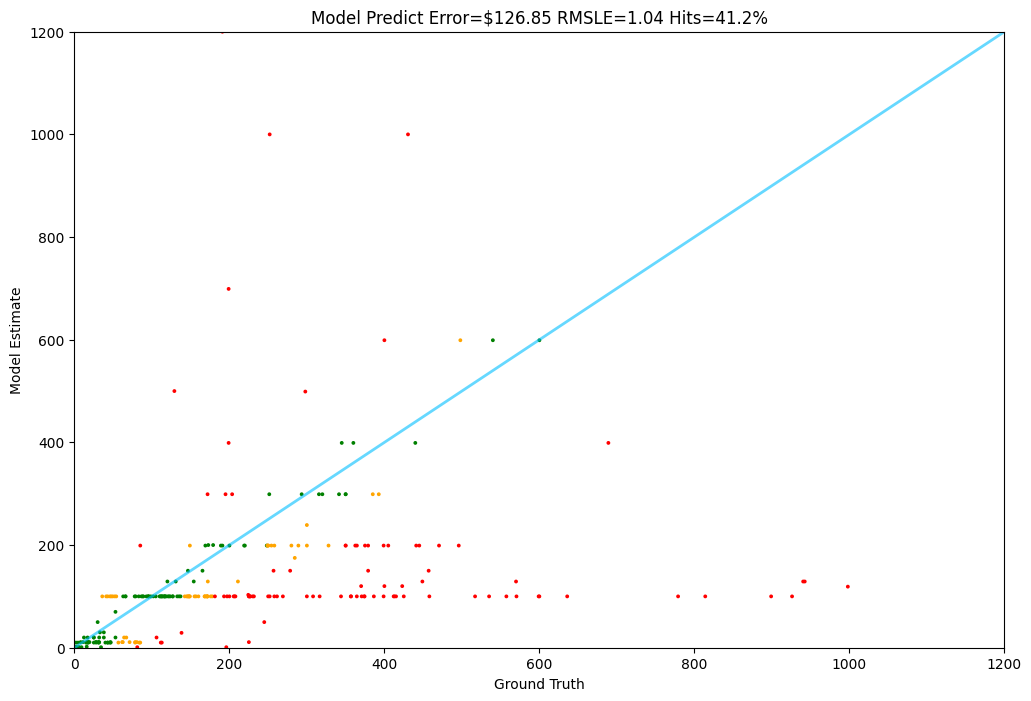

In [21]:
Tester.test(model_predict, test)